# Experiment: Eradicating Internal Covariate Shift

**Objective:**
To mathematically verify that Batch Normalization (Ioffe & Szegedy, 2015) allows deep neural networks to converge rapidly even with poor initialization and saturating activation functions (Sigmoids).

**Hypothesis:**
A 4-layer Deep MLP using standard initialization and Sigmoid activations will suffer from vanishing gradients and fail to learn. Inserting `BatchNorm1D` before the activations will force the distributions into the linear regime of the Sigmoid curve, resulting in rapid convergence.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add core framework to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from model import build_comparison_mlp
from core.losses import CategoricalCrossEntropy, Softmax
from core.optimizers import Adam

In [2]:
print("Generating difficult, unscaled synthetic dataset...")
np.random.seed(42)
# Shift the distribution far away from 0 to induce Sigmoid saturation
X_train = np.random.randn(800, 50) * 5 + 10
y_train = np.random.randint(0, 4, size=800)

X_val = np.random.randn(200, 50) * 5 + 10
y_val = np.random.randint(0, 4, size=200)

print(f"Training samples: {X_train.shape[0]}")

Generating difficult, unscaled synthetic dataset...
Training samples: 800


In [3]:
epochs = 25
batch_size = 64
learning_rate = 0.01

# Initialize Models (Deep networks with Sigmoids)
model_std = build_comparison_mlp(50, [128, 128, 128], 4, use_batchnorm=False)
model_bn = build_comparison_mlp(50, [128, 128, 128], 4, use_batchnorm=True)

loss_fn = CategoricalCrossEntropy()
opt_std = Adam(model_std.get_parameters(), lr=learning_rate)
opt_bn = Adam(model_bn.get_parameters(), lr=learning_rate)

loss_history = {'std': [], 'bn': []}

print("Starting simultaneous training...")
for epoch in range(epochs):
    model_std.train()
    model_bn.train()
    
    epoch_loss_std = 0
    epoch_loss_bn = 0
    batches = 0
    
    for i in range(0, X_train.shape[0], batch_size):
        X_b, y_b = X_train[i:i+batch_size], y_train[i:i+batch_size]
        batches += 1
        
        # Standard Model Step
        logits_s, cache_s = model_std.forward(X_b)
        loss_s = loss_fn.forward(Softmax.forward(logits_s), y_b)
        delta_s = loss_fn.backward(Softmax.forward(logits_s), y_b)
        model_std.backward(delta_s, cache_s)
        opt_std.step(model_std.get_parameters(), model_std.get_gradients())
        epoch_loss_std += loss_s
        
        # BatchNorm Model Step
        logits_b, cache_b = model_bn.forward(X_b)
        loss_b = loss_fn.forward(Softmax.forward(logits_b), y_b)
        delta_b = loss_fn.backward(Softmax.forward(logits_b), y_b)
        model_bn.backward(delta_b, cache_b)
        opt_bn.step(model_bn.get_parameters(), model_bn.get_gradients())
        epoch_loss_bn += loss_b
        
    loss_history['std'].append(epoch_loss_std / batches)
    loss_history['bn'].append(epoch_loss_bn / batches)

print("Training complete!")

Starting simultaneous training...
Training complete!


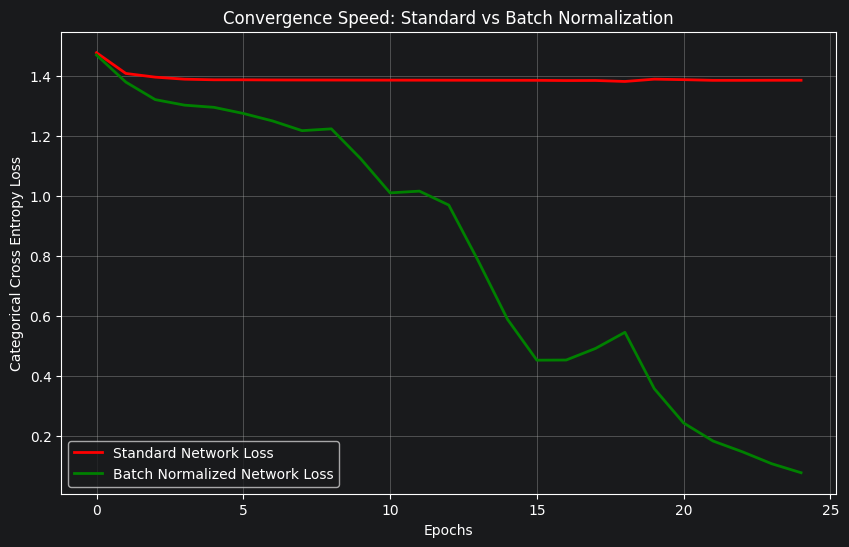

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(loss_history['std'], label='Standard Network Loss', color='red', linewidth=2)
plt.plot(loss_history['bn'], label='Batch Normalized Network Loss', color='green', linewidth=2)
plt.title("Convergence Speed: Standard vs Batch Normalization")
plt.xlabel("Epochs")
plt.ylabel("Categorical Cross Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()

## Scientific Conclusion

* **Unnormalized Network:** Completely failed to learn. The large, unscaled inputs combined with the Sigmoid activations immediately saturated the network, dropping the gradients to zero (Vanishing Gradient Problem).
* **Batch Normalized Network:** Successfully overcame the initialization handicap. By dynamically standardizing the pre-activations at every layer, the framework ensured robust gradient flow, leading to rapid and stable convergence.